In [16]:
import copy, math
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('./deeplearning.mplstyle')
np.set_printoptions(precision=2)  # reduced display precision on numpy arrays

In [17]:
X_train = np.array([[2104, 5, 1, 45], [1416, 3, 2, 40], [852, 2, 1, 35]])
y_train = np.array([460, 232, 178])

In [18]:
# data is stored in numpy array/matrix
print(f"X Shape: {X_train.shape}, X Type:{type(X_train)})")
print(X_train)
print(f"y Shape: {y_train.shape}, y Type:{type(y_train)})")
print(y_train)

X Shape: (3, 4), X Type:<class 'numpy.ndarray'>)
[[2104    5    1   45]
 [1416    3    2   40]
 [ 852    2    1   35]]
y Shape: (3,), y Type:<class 'numpy.ndarray'>)
[460 232 178]


In [4]:
b_init = 785.1811367994083
w_init = np.array([ 0.39133535, 18.75376741, -53.36032453, -26.42131618])
print(f"w_init shape: {w_init.shape}, b_init type: {type(b_init)}")

w_init shape: (4,), b_init type: <class 'float'>


In [5]:
# use single for loop without no vectorizations
def predict_single_loop(x, w, b):
    n = x.shape[0]
    pred = 0

    for i in range(n):
        p_i = x[i] * w[i]
        pred += p_i
    pred += b
    return pred

In [6]:
# get a row from our training data
x_vec = X_train[0,:]
print(f"x_vec shape {x_vec.shape}, x_vec value: {x_vec}")

# make a prediction
f_wb = predict_single_loop(x_vec, w_init, b_init)
print(f"f_wb shape {f_wb.shape}, prediction: {f_wb}")

x_vec shape (4,), x_vec value: [2104    5    1   45]
f_wb shape (), prediction: 459.9999976194083


In [7]:
# Using dot product
def predict(x, w, b):
    return np.dot(x, w) + b

In [8]:
# get a row from our training data
x_vec = X_train[0,:]
print(f"x_vec shape {x_vec.shape}, x_vec value: {x_vec}")

# make a prediction
f_wb = predict(x_vec,w_init, b_init)
print(f"f_wb shape {f_wb.shape}, prediction: {f_wb}")

x_vec shape (4,), x_vec value: [2104    5    1   45]
f_wb shape (), prediction: 459.9999976194083


In [9]:
def compute_cost(x, y, w, b):
    m = x.shape[0]
    cost = 0.0
    for i in range(m):
        f_wb_i = np.dot(x[i], w) + b
        cost += (f_wb_i - y[i]) ** 2
    cost /= (2 * m)
    return cost

In [10]:
# Compute and display cost using our pre-chosen optimal parameters. 
cost = compute_cost(X_train, y_train, w_init, b_init)
print(f'Cost at optimal w : {cost}')

Cost at optimal w : 1.5578904428966628e-12


In [11]:
# gradient descent
def compute_gradient(x, y, w, b):
    m, n = x.shape
    dj_dw = np.zeros((n, ))
    dj_db = 0

    for i in range(m):
        err = (np.dot(x[i], w.T) + b) - y[i]
        for j in range(n):
            dj_dw[j] = dj_dw[j] + err * x[i, j]
        dj_db = dj_db + err                        
    dj_dw = dj_dw / m                                
    dj_db = dj_db / m                                
        
    return dj_db, dj_dw 

In [12]:
# 1) Hypothesis: f(w, b, x) = w·x + b
def f(w, b, x):
    # 1.1) np.dot(x, w) does the vector‑dot‑product; then add b (scalar)
    return np.dot(x, w) + b

# 2) Cost function: J(w,b) = (1/2m) Σ (f(x) − y)²
def J(w, b, x, y):
    m = len(x)                           # 2.1) number of samples
    errors = f(w, b, x) - y              # 2.2) vector of (prediction − truth)
    return (1 / (2 * m)) * np.sum(errors**2)

# 3) Compute gradient ∂J/∂b, ∂J/∂w
def compute_gradient(x, y, w, b):
    m, n = x.shape                       # 3.1) m = samples, n = features
    dj_dw = np.zeros((n, ))              # 3.2) initialize gradient vector for w
    dj_db = 0                            # 3.3) initialize gradient scalar for b

    # 3.4) Loop over each sample i = 0…m−1
    for i in range(m):
        # 3.4.1) Compute error on sample i
        #        err = (w·x[i] + b) − y[i]
        err = (np.dot(x[i], w) + b) - y[i]

        # 3.4.2) Loop over each feature j = 0…n−1
        for j in range(n):
            # 3.4.2.1) Accumulate partial derivative wrt w[j]:
            #            ∂/∂w[j] of (err²) = 2·err·x[i,j],
            #            but factor 2 is canceled by the 1/2 in J, so just err·x[i,j]
            dj_dw[j] += err * x[i, j]

        # 3.4.3) Accumulate partial derivative wrt b:
        #         ∂/∂b of (err²) = 2·err, again 2 cancels out
        dj_db += err

    # 3.5) Average over all samples
    dj_dw /= m
    dj_db /= m

    # 3.6) Return gradients in the order (db, dw)
    return dj_db, dj_dw

# 4) Gradient descent with tracing
def gradient_descent_trace(x, y, w_init, b_init, α, iterations):
    w = w_init.copy()                   # 4.1) start with initial w
    b = b_init                          # 4.2) start with initial b
    cost_history = []                   # 4.3) to record J(w,b) each iter

    # 4.4) Main loop: iterate gradient descent steps
    for it in range(iterations):
        # 4.4.1) Compute gradients at current (w, b)
        dj_db, dj_dw = compute_gradient(x, y, w, b)

        # 4.4.2) TRACE PRINT the raw gradient values before update
        print(f"Iter {it+1} raw grads -> dj_dw: {dj_dw}, dj_db: {dj_db}")

        # 4.4.3) Update parameters:
        #         w_new = w_old − α·(dj_dw)
        #         b_new = b_old − α·(dj_db)
        w -= α * dj_dw
        b -= α * dj_db

        # 4.4.4) Compute and record cost after the update
        cost = J(w, b, x, y)
        cost_history.append(cost)

        # 4.4.5) TRACE PRINT the new parameters & cost
        print(f"       updated -> w: {w}, b: {b}, cost: {cost}\n")

    return w, b, cost_history

In [13]:
# initialize parameters
initial_w = np.zeros_like(w_init)
initial_b = 0.
# some gradient descent settings
iterations = 1000
alpha = 5.0e-7
# run gradient descent 
w_final, b_final, J_hist = gradient_descent_trace(X_train, y_train, initial_w, initial_b,
                                                    alpha, iterations)
print(f"b,w found by gradient descent: {b_final:0.2f},{w_final} ")
m,_ = X_train.shape
for i in range(m):
    print(f"prediction: {np.dot(X_train[i], w_final) + b_final:0.2f}, target value: {y_train[i]}")

Iter 1 raw grads -> dj_dw: [-4.83e+05 -1.12e+03 -3.67e+02 -1.21e+04], dj_db: -290.0
       updated -> w: [2.41e-01 5.59e-04 1.84e-04 6.03e-03], b: 0.000145, cost: 2529.46295223163

Iter 2 raw grads -> dj_dw: [93505.19   208.6     98.61  2511.64], dj_db: 61.94870633333326
       updated -> w: [1.95e-01 4.54e-04 1.34e-04 4.78e-03], b: 0.00011402564683333336, cost: 765.8336829952987

Iter 3 raw grads -> dj_dw: [-1.81e+04 -4.83e+01  8.34e+00 -3.13e+02], dj_db: -6.236084502424073
       updated -> w: [2.04e-01 4.79e-04 1.30e-04 4.94e-03], b: 0.00011714368908454539, cost: 699.6290280210451

Iter 4 raw grads -> dj_dw: [3.51e+03 1.49e+00 2.58e+01 2.34e+02], dj_db: 6.973372066169115
       updated -> w: [2.02e-01 4.78e-04 1.17e-04 4.82e-03], b: 0.00011365700305146083, cost: 697.1337425623085

Iter 5 raw grads -> dj_dw: [-683.62   -8.16   22.44  127.92], dj_db: 4.413975284388272
       updated -> w: [2.02e-01 4.82e-04 1.06e-04 4.75e-03], b: 0.00011145001540926669, cost: 697.0296591788103

Iter 6

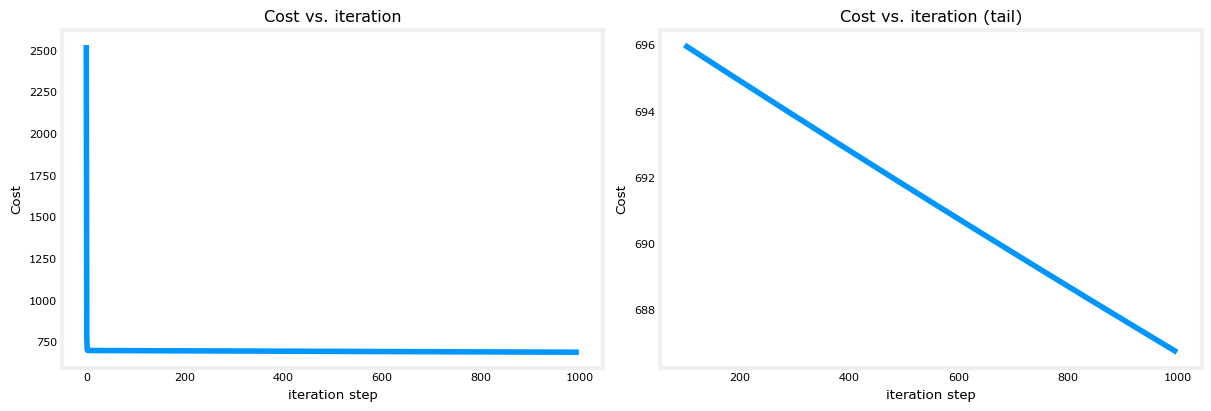

In [14]:
fig, (ax1, ax2) = plt.subplots(1, 2, constrained_layout=True, figsize=(12, 4))
ax1.plot(J_hist)
ax2.plot(100 + np.arange(len(J_hist[100:])), J_hist[100:])
ax1.set_title("Cost vs. iteration");  ax2.set_title("Cost vs. iteration (tail)")
ax1.set_ylabel('Cost')             ;  ax2.set_ylabel('Cost') 
ax1.set_xlabel('iteration step')   ;  ax2.set_xlabel('iteration step') 
plt.show()